In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as colors
import xarray as xr
import geopandas as gpd
import contextily as cx
import numpy as np
from scores.continuous import kge
from val_utils import *
sns.set_theme()

In [240]:
csi_in = xr.open_dataset("../data/CSI_inputdata.nc")
csii_in = xr.open_dataset("../data/CSII_inputdata.nc")
csiii_in = xr.open_dataset("../data/CSIII_inputdata.nc")
csiv_in = xr.open_dataset("../data/CSIV_inputdata.nc")

csi_aoi = gpd.read_file("../data/CSI_aoi.shp")
csii_aoi = gpd.read_file("../data/CSII_aoi.shp")
csiii_aoi = gpd.read_file("../data/CSIII_aoi.shp")
csiv_aoi = gpd.read_file("../data/CSIV_aoi.shp")

<h2>Case study selection plot

In [241]:

csi_in = csi_in.rio.write_crs("EPSG:4326")
csii_in = csii_in.rio.write_crs("EPSG:4326")
csiii_in = csiii_in.rio.write_crs("EPSG:4326")
csiv_in = csiv_in.rio.write_crs("EPSG:4326")


csi_ore = csi_in["ore"].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
csii_ore = csii_in["ore"].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
csiii_ore = csiii_in["ore"].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
csiv_ore = csiv_in["ore"].rio.set_spatial_dims(x_dim="lon", y_dim="lat")

from shapely.geometry import mapping

csi_aoi = csi_aoi.to_crs(csi_in.rio.crs)
csii_aoi = csii_aoi.to_crs(csii_in.rio.crs)
csiii_aoi = csiii_aoi.to_crs(csiii_in.rio.crs)
csiv_aoi = csiv_aoi.to_crs(csiv_in.rio.crs)

geoms_i = [mapping(geom) for geom in csi_aoi.geometry]
geoms_ii = [mapping(geom) for geom in csii_aoi.geometry]
geoms_iii = [mapping(geom) for geom in csiii_aoi.geometry]
geoms_iv = [mapping(geom) for geom in csiv_aoi.geometry]

csi_ore = csi_ore.rio.clip(
    geoms_i,
    csi_aoi.crs,
    drop=True,
    all_touched=True
)

csii_ore = csii_ore.rio.clip(
    geoms_ii,
    csii_aoi.crs,
    drop=True,
    all_touched=True
)

csiii_ore = csiii_ore.rio.clip(
    geoms_iii,
    csiii_aoi.crs,
    drop=True,
    all_touched=True
)

csiv_ore = csiv_ore.rio.clip(
    geoms_iv,
    csiv_aoi.crs,
    drop=True,
    all_touched=True
)


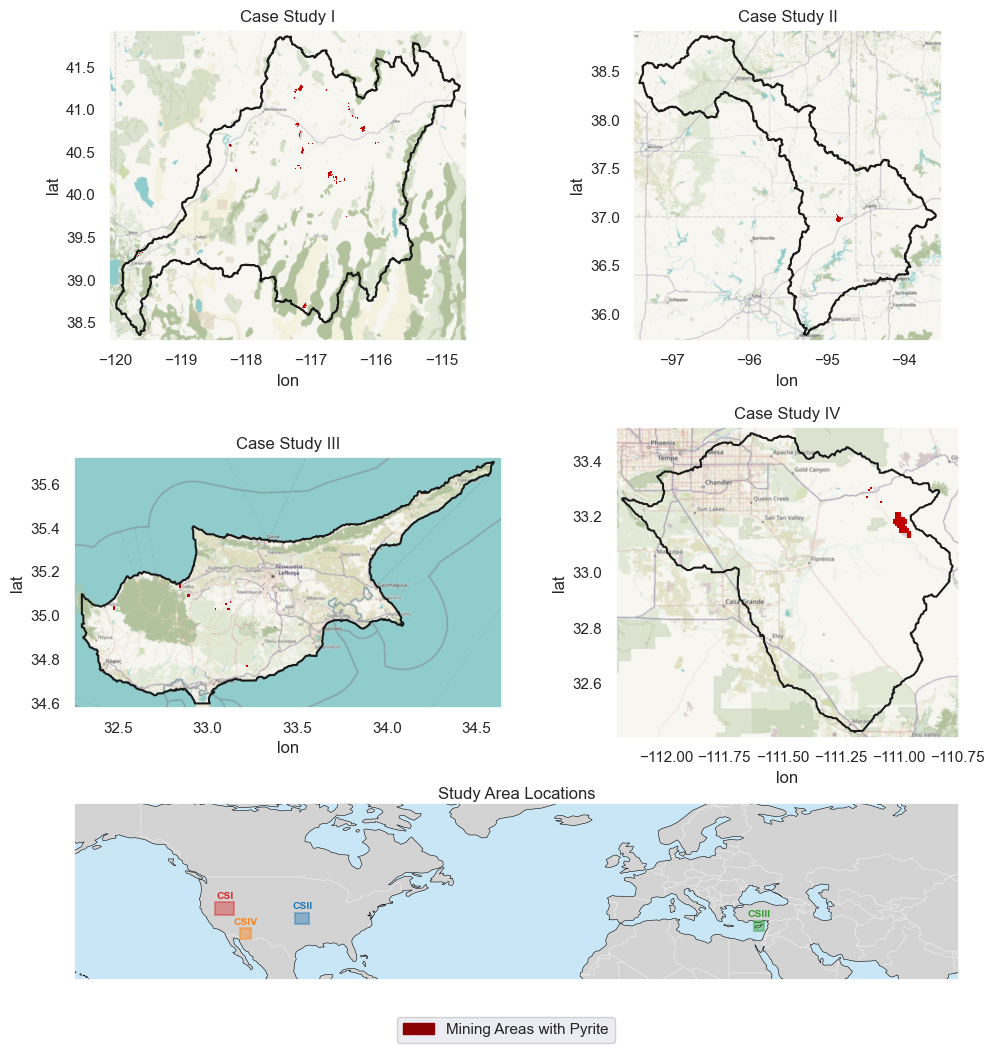

In [242]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

red_patch = mpatches.Patch(color="darkred", label="Mining Areas with Pyrite")

fig = plt.figure(figsize=(10, 11), layout = "constrained")
gs = GridSpec(
    3, 2, figure=fig,
    height_ratios=[4, 4, 4],  
    hspace=0.05, wspace=0.1,
)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

csi_ore.plot(ax=ax1, cmap="gist_heat", add_colorbar=False)
csi_aoi.boundary.plot(ax=ax1, edgecolor="k")
ax1.set_title("Case Study I")
cx.add_basemap(ax1, crs=csi_aoi.crs.to_string(), attribution=False)
ax1.set_xlabel("lon"); ax1.set_ylabel("lat")

csii_ore.plot(ax=ax2, cmap="gist_heat", add_colorbar=False)
csii_aoi.boundary.plot(ax=ax2, edgecolor="k")
ax2.set_title("Case Study II")
cx.add_basemap(ax2, crs=csii_aoi.crs.to_string(), attribution=False)
ax2.set_xlabel("lon"); ax2.set_ylabel("lat")

csiii_ore.plot(ax=ax3, cmap="gist_heat", add_colorbar=False)
csiii_aoi.boundary.plot(ax=ax3, edgecolor="k")
ax3.set_title("Case Study III")
cx.add_basemap(ax3, crs=csiii_aoi.crs.to_string(), attribution=False)
ax3.set_xlabel("lon"); ax3.set_ylabel("lat")

csiv_ore.plot(ax=ax4, cmap="gist_heat", add_colorbar=False)
csiv_aoi.boundary.plot(ax=ax4, edgecolor="k")
ax4.set_title("Case Study IV")
cx.add_basemap(ax4, crs=csiv_aoi.crs.to_string(), attribution=False)
ax4.set_xlabel("lon"); ax4.set_ylabel("lat")

for ax, aoi in [(ax1, csi_aoi), (ax2, csii_aoi), (ax3, csiii_aoi), (ax4, csiv_aoi)]:
    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx*pad, bounds[2] + dx*pad)
    ax.set_ylim(bounds[1] - dy*pad, bounds[3] + dy*pad)

fig.canvas.draw()

left_edge = ax3.get_position().x0
right_edge = ax4.get_position().x1
map_width = right_edge - left_edge

ax_world = fig.add_axes([left_edge, 0.08, map_width, 0.23], projection=ccrs.PlateCarree())

ax_world.set_extent([-160, 90, 20, 70], crs=ccrs.PlateCarree())

ax_world.add_feature(cfeature.LAND,      facecolor="lightgray", zorder=0)
ax_world.add_feature(cfeature.OCEAN,     facecolor="#c8e6f5",   zorder=0)
ax_world.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor="white", zorder=1)
ax_world.add_feature(cfeature.COASTLINE, linewidth=0.4, zorder=1)

cs_configs = [
    (csi_aoi,   "CSI",   "#d62728"),
    (csii_aoi,  "CSII",  "#1f77b4"),
    (csiii_aoi, "CSIII", "#2ca02c"),
    (csiv_aoi,  "CSIV",  "#ff7f0e"),
]

MIN_DEG = 3

for aoi, name, color in cs_configs:
    b = aoi.to_crs(epsg=4326).total_bounds
    mid_x = (b[0] + b[2]) / 2
    mid_y = (b[1] + b[3]) / 2
    w = max(b[2] - b[0], MIN_DEG)
    h = max(b[3] - b[1], MIN_DEG)

    ax_world.add_patch(mpatches.Rectangle(
        (mid_x - w/2, mid_y - h/2), w, h,
        transform=ccrs.PlateCarree(),
        linewidth=1.5, edgecolor=color, facecolor=color,
        alpha=0.4, zorder=3,
    ))
    ax_world.text(
        mid_x, mid_y + h/2 + 0.5, name,
        transform=ccrs.PlateCarree(),
        ha="center", va="bottom",
        fontsize=7.5, fontweight="bold", color=color, zorder=4,
    )

ax_world.set_title("Study Area Locations", fontsize=12, pad=3)

fig.legend(
    handles=[red_patch],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    framealpha=0.9,
    ncol=1
)

fig.savefig("../images/case_studies.png", dpi=300, bbox_inches="tight")

<h2>Cross-site validation

In [5]:
time_first = "1960"
time_last = "2015"
case_study_nr_list = ["CSI", "CSII", "CSIII", "CSIV"]
region_codes = ["na", "na", "eu", "na"]
crss = ["EPSG:26912", "EPSG:26912", "EPSG:3612","EPSG:26912"]

In [6]:
for i in [0, 1, 2, 3]:
    case_study_nr = case_study_nr_list[i]
    times = (time_first, time_last)
    metre_crs = crss[i]
    hydrobasins_region_code = region_codes[i]
    caravan_path = "../data/validation data/Caravan-Qual_lite.zarr"
    amd_path = f"../data/validation data/AMDFLOW_{case_study_nr}_{time_first}-{time_last}_W.nc"
    output_path = f"../data/validation data/{case_study_nr}/"
    acc_path = f"../data/validation data/hyd_{hydrobasins_region_code}_acc_30s.tif"
    rivers_path = f"../data/validation data/HydroRIVERS_v10_{hydrobasins_region_code}_shp/HydroRIVERS_v10_{hydrobasins_region_code}.shp"

    utm_crs = metre_crs #"EPSG:6312" (Cyprus),  "EPSG:24378" (India) "EPSG: 3761" #(Canada)
    resample_freq = "W"
    var_map = {
        "pH": "pH",
        "Fe-Dis": ["ferrous_iron", "ferric_iron"],
        "Fe-Tot": ["ferrous_iron", "ferric_iron", "ferric_oxyhydroxide"],
    }

    print(f"Validating AMDFLOW Case Study {case_study_nr} ({time_first}–{time_last}),")
    print("against Caravan-Qual Lite using HydroSHEDS network + area ratio snapping.")

    # load everything
    amd, caravan, acc_array, acc_transform, acc_nodata, rivers= load_datasets(
        amd_path, caravan_path, acc_path, rivers_path
    )

    candidates = wqms_stations_domain_filter(amd, caravan)

    # get masks
    (valid_ilat, valid_ilon, valid_lat, valid_lon,
        iron_ilat, iron_ilon, iron_lat, iron_lon,
        valid_mask, iron_mask) = valid_masking(amd)

    # build river graph
    river_graph = build_river_graph(rivers)

    # 2D lat/lon grids
    lat_vals = amd.lat.values
    lon_vals = amd.lon.values
    amd_lat_2d, amd_lon_2d = np.meshgrid(lat_vals, lon_vals, indexing="ij")

    # upstream areas from ACC
    uparea_dict = assign_uparea_from_acc(amd, amd_lat_2d, amd_lon_2d, valid_mask,
                                            acc_array, acc_transform, acc_nodata)

    # snap AMD cells to river network (once)
    cell_to_river = snap_cells_to_river(amd_lat_2d, amd_lon_2d, valid_mask, rivers, utm_crs)
    print(f"Cells snapped to river: {len(cell_to_river)}")
    # snap stations for pH mask
    matches_ph = snap_stations_hydrosheds(
        candidates, amd_lat_2d, amd_lon_2d, valid_mask,
        uparea_dict, cell_to_river, rivers, river_graph, utm_crs,
        max_network_km=20.0, area_ratio_min=0.5, area_ratio_max=1.5
    )

    # snap stations for iron mask
    iron_cells = [(ilat, ilon) for ilat, ilon in zip(*np.where(iron_mask))]
    iron_uparea_dict = {k: uparea_dict.get(k, np.nan) for k in iron_cells}
    iron_cell_to_river = {k: v for k, v in cell_to_river.items() if k in iron_cells}

    matches_iron = snap_stations_hydrosheds(
        candidates, amd_lat_2d, amd_lon_2d, iron_mask,
        iron_uparea_dict, iron_cell_to_river, rivers, river_graph, utm_crs,
        max_network_km=20.0, area_ratio_min=0.5, area_ratio_max=1.5
    )

    print(f"  pH mask:   {len(matches_ph)} stations matched")
    print(f"  Iron mask: {len(matches_iron)} stations matched")

    # run full validation
    all_results = full_run(var_map, matches_ph, matches_iron, amd, caravan,
                            min_paired_obs=3, resample_freq=resample_freq)

    for var, ts in all_results.items():
        print(f"\n── {var} ──────────────────────────────────────────")
        metrics = validation_metrics(ts)
        
        # add coordinates for matched stations (pH and iron may differ)
        if var in ["Fe-Dis", "Fe-Tot"]:
            match_df = matches_iron
        else:
            match_df = matches_ph
        
        coords = match_df[["wqms_id", "cell_lat", "cell_lon"]].set_index("wqms_id")
        results_df = metrics.join(coords)
        
        os.makedirs(output_path, exist_ok=True)
        results_df.to_csv(f"{output_path}metrics_{var}.csv")
        print(f"  Saved → {output_path}metrics_{var}.csv\n  With {len(results_df)} matched stations and their metrics.")

Validating AMDFLOW Case Study CSI (1960–2015),
against Caravan-Qual Lite using HydroSHEDS network + area ratio snapping.

Loading all datasets.....
384 stations fall inside (or near) the AMD domain

Computing valid-cell mask …
  2,574 valid cells (pH mask)
  2,574 iron cells
Assigning upstream watershed area to cells from flow accumulation
Snapping cells to river(s)
Cells snapped to river: 2574
Snapping stations to rivers and then cells
Snapping stations to rivers and then cells
  pH mask:   62 stations matched
  Iron mask: 62 stations matched
  Overlapping period: 1980-01-01 → 2015-10-19
  Reading 25 unique AMD cells (covers 62 stations) …
  AMD variable(s): pH
  717 / 115,816 timesteps have paired observations (0.6 %)
  Recording 28 station(s) with < 3 paired observations
  Overlapping period: 1980-01-01 → 2015-10-19
  Reading 25 unique AMD cells (covers 62 stations) …
  AMD variable(s): ferrous_iron+ferric_iron
  167 / 115,816 timesteps have paired observations (0.1 %)
  Recording 1

<h2>Scatterplots of observed vs. modelled values

In [ ]:
def _get_amd_var_names(caravan_var):
    if caravan_var == "pH":
        return ["pH"]
    if caravan_var == "Fe-Dis":
        return ["ferrous_iron", "ferric_iron"]
    if caravan_var == "Fe-Tot":
        return ["ferrous_iron", "ferric_iron", "ferric_oxyhydroxide"]
    raise ValueError(f"Unknown caravan variable: {caravan_var}")


def extract_case_pairs(case_name, case_csv, amd_path, caravan_path,
                       caravan_var, resample_freq="W", tol_days=14):
    matches = pd.read_csv(case_csv)
    matches = matches.dropna(subset=["wqms_id", "cell_lat", "cell_lon"])
    matches["wqms_id"] = matches["wqms_id"].astype(str)

    amd = xr.open_dataset(amd_path, chunks={})
    caravan = xr.open_dataset(caravan_path, engine="zarr", chunks={})

    vars_ = _get_amd_var_names(caravan_var)
    obs = caravan[caravan_var].sel(wqms_id=matches["wqms_id"].unique())
    if resample_freq:
        obs = obs.resample(time=resample_freq).mean(skipna=True)
    obs_df = obs.to_series().rename("observed").reset_index()
    obs_df["time"] = pd.to_datetime(obs_df["time"])

    model_frames = []
    cell_df = matches[["wqms_id", "cell_lat", "cell_lon"]].drop_duplicates()
    for _, row in cell_df.iterrows():
        if len(vars_) == 1:
            data = amd[vars_[0]].sel(lat=row["cell_lat"], lon=row["cell_lon"], method="nearest")
        else:
            data = sum(
                amd[v].sel(lat=row["cell_lat"], lon=row["cell_lon"], method="nearest")
                * ((55.845 / 106.87) if v == "ferric_oxyhydroxide" else 1)
                for v in vars_
            )

        model_df = data.to_series().rename("modelled").reset_index()
        model_df["time"] = pd.to_datetime(model_df["time"])
        model_df["wqms_id"] = row["wqms_id"]
        model_frames.append(model_df)

    amd.close()
    caravan.close()

    model_df = pd.concat(model_frames, ignore_index=True)
    model_df = model_df.sort_values(["wqms_id", "time"]).reset_index(drop=True)
    obs_df = obs_df.sort_values(["wqms_id", "time"]).reset_index(drop=True)

    paired_frames = []
    for wqms_id, obs_group in obs_df.groupby("wqms_id"):
        model_group = model_df[model_df["wqms_id"] == wqms_id]
        if model_group.empty:
            continue
        obs_group = obs_group.sort_values("time")
        model_group = model_group.sort_values("time")
        paired = pd.merge_asof(
            obs_group,
            model_group,
            on="time",
            direction="nearest",
            tolerance=pd.Timedelta(f"{tol_days}D")
        )
        paired_frames.append(paired)

    if paired_frames:
        paired = pd.concat(paired_frames, ignore_index=True)
    else:
        paired = pd.DataFrame(columns=["wqms_id", "time", "observed", "modelled"])

    paired = paired.dropna(subset=["observed", "modelled"])
    paired["case_study"] = case_name
    return paired


def plot_variable_corr_all_cases(variable_name, case_infos, resample_freq="W", tol_days=14, 
                                 show_kge=False, log_scale=False, text_position="upper left",
                                 unit = "", output = None, ylim = None, xlim = None):
    frames = []
    for case_name, case_csv, amd_path in case_infos:
        frames.append(extract_case_pairs(
            case_name,
            case_csv,
            amd_path,
            "../data/validation data/Caravan-Qual_lite.zarr",
            variable_name,
            resample_freq=resample_freq,
            tol_days=tol_days
        ))

    all_df = pd.concat(frames, ignore_index=True)
    if all_df.empty:
        raise ValueError("No paired observations were found for any case study.")

    mn = min(all_df["observed"].min(), all_df["modelled"].min())
    mx = max(all_df["observed"].max(), all_df["modelled"].max())

    fig = plt.figure(figsize=(8, 8))
    case_palette = {
        "CSI": "blue",
        "CSII": "orange",
        "CSIII": "purple",
        "CSIV": "red",
    }
    sns.scatterplot(
        data=all_df,
        x="modelled",
        y="observed",
        hue="case_study",
        palette=case_palette,
        alpha=0.6
    )
    plt.legend(title="", framealpha=0.7, facecolor="white", edgecolor="none", fontsize=10)
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=1)
    plt.xlabel(f"Modelled {unit}")
    plt.ylabel(f"Observed {unit}")
    print(f"Modelled vs Observed: {variable_name} (all case studies)")
    if log_scale:
        plt.xscale("log")
        plt.yscale("log")
    plt.xlim(mn, mx)
    plt.ylim(mn, mx)

    summary_lines = []
    for case_name, group in all_df.groupby("case_study"):

        rmse = sc.continuous.rmse(group["observed"].values, 
                                  group["modelled"].values)
        if show_kge:
            obs_da = xr.DataArray(group["observed"].values, coords={"time": group["time"]}, dims=["time"])
            model_da = xr.DataArray(group["modelled"].values, coords={"time": group["time"]}, dims=["time"])
            kge_val = float(kge(model_da, obs_da).item())
            summary_lines.append(f"{case_name}: $RMSE$={rmse:.2f}, KGE={kge_val:.2f}")
        else:
            summary_lines.append(f"{case_name}: $RMSE$={rmse:.2f}")

    position_map = {
        "upper left": {"x": 0.02, "y": 0.98, "va": "top", "ha": "left"},
        "upper right": {"x": 0.98, "y": 0.98, "va": "top", "ha": "right"},
        "lower left": {"x": 0.02, "y": 0.02, "va": "bottom", "ha": "left"},
        "lower right": {"x": 0.98, "y": 0.02, "va": "bottom", "ha": "right"},
    }
    
    if text_position not in position_map:
        raise ValueError(f"text_position must be one of {list(position_map.keys())}, got '{text_position}'")
    
    pos = position_map[text_position]
    plt.gca().text(
        pos["x"],
        pos["y"],
        "\n".join(summary_lines),
        transform=plt.gca().transAxes,
        verticalalignment=pos["va"],
        horizontalalignment=pos["ha"],
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if ylim:
        plt.ylim(ylim[0], ylim[1])
    if xlim:
        plt.xlim(xlim[0], xlim[1])
    plt.show()
    if output:
        fig.savefig(output, dpi = 300, bbox_inches = "tight")

Modelled vs Observed: Fe-Dis (all case studies)


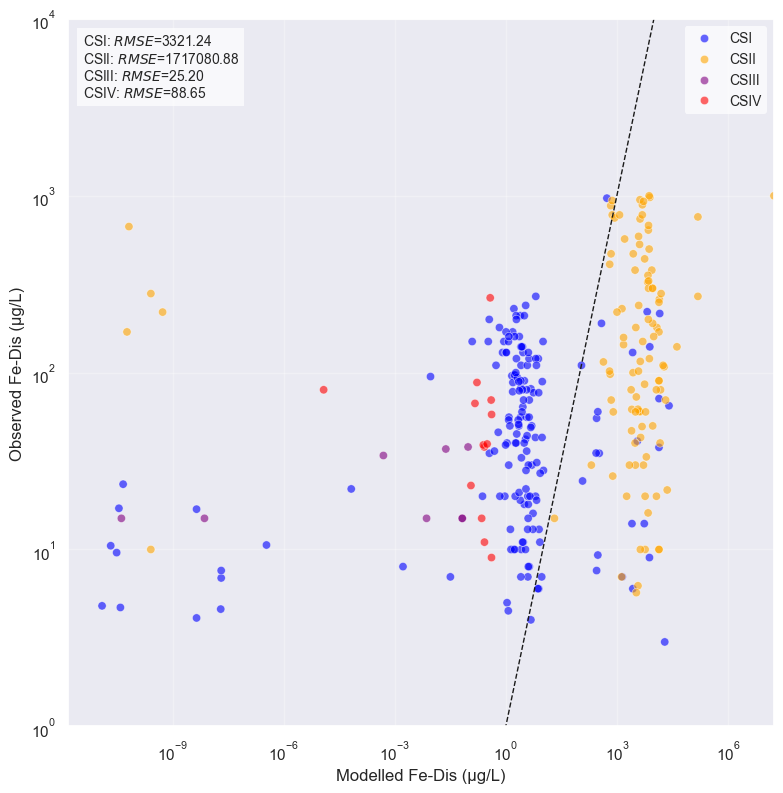

In [85]:
case_infos = [
    ("CSI",  "../data/validation data/CSI/metrics_Fe-Dis.csv",  "../data/validation data/AMDFLOW_CSI_1960-2015_W.nc"),
    ("CSII", "../data/validation data/CSII/metrics_Fe-Dis.csv", "../data/validation data/AMDFLOW_CSII_1960-2015_W.nc"),
    ("CSIII", "../data/validation data/CSIII/metrics_Fe-Dis.csv", "../data/validation data/AMDFLOW_CSIII_1960-2015_W.nc"),
    ("CSIV", "../data/validation data/CSIV/metrics_Fe-Dis.csv", "../data/validation data/AMDFLOW_CSIV_1960-2015_W.nc"),
]

plot_variable_corr_all_cases("Fe-Dis", case_infos, resample_freq="W", show_kge=False, log_scale=True, unit = "Fe-Dis (µg/L)",
                             output = "../images/corr_fe_dis.png", ylim=(1e0, 1e4))

Modelled vs Observed: pH (all case studies)


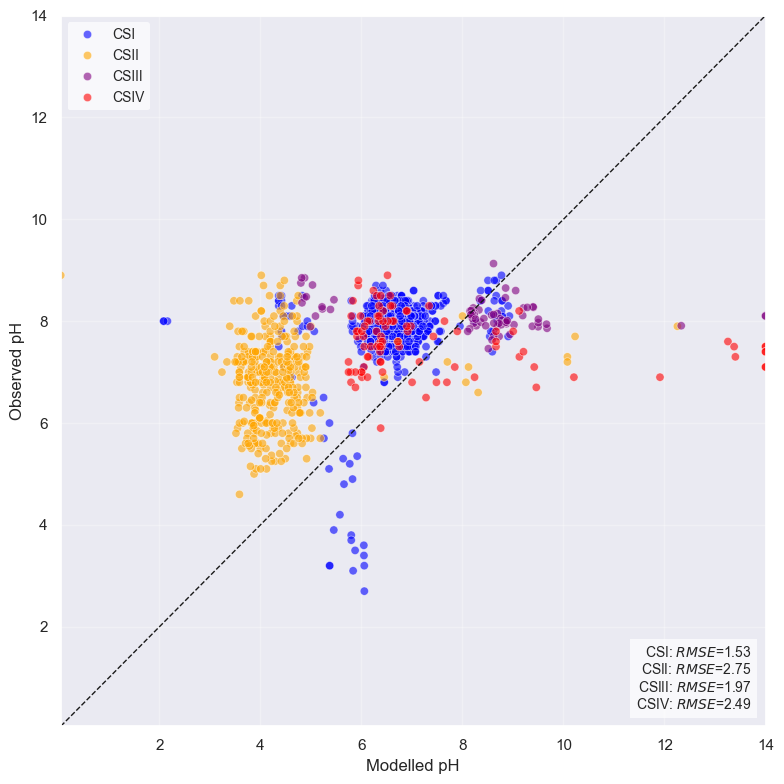

In [9]:
case_infos = [
    ("CSI",  "../data/validation data/CSI/metrics_pH.csv",  "../data/validation data/AMDFLOW_CSI_1960-2015_W.nc"),
    ("CSII", "../data/validation data/CSII/metrics_pH.csv", "../data/validation data/AMDFLOW_CSII_1960-2015_W.nc"),
    ("CSIII", "../data/validation data/CSIII/metrics_pH.csv", "../data/validation data/AMDFLOW_CSIII_1960-2015_W.nc"),
    ("CSIV", "../data/validation data/CSIV/metrics_pH.csv", "../data/validation data/AMDFLOW_CSIV_1960-2015_W.nc"),
]

plot_variable_corr_all_cases("pH", case_infos, resample_freq="W", show_kge=False, text_position= "lower right",
                             output = "../images/corr_ph.png", unit = "pH")

<h2>FZE violinplots

In [6]:
csi_ph = pd.read_csv("../data/validation data/CSI/Metrics_pH.csv", skipfooter=-1).dropna()
csi_fe_dis = pd.read_csv("../data/validation data/CSI/Metrics_Fe-Dis.csv", skipfooter=-1).dropna()
csi_fe_tot = pd.read_csv("../data/validation data/CSI/Metrics_Fe-Tot.csv", skipfooter=-1).dropna()

csii_ph = pd.read_csv("../data/validation data/CSII/Metrics_pH.csv", skipfooter=-1).dropna()
csii_fe_dis = pd.read_csv("../data/validation data/CSII/Metrics_Fe-Dis.csv", skipfooter=-1).dropna()
csii_fe_tot = pd.read_csv("../data/validation data/CSII/Metrics_Fe-Tot.csv", skipfooter=-1).dropna()

csiii_ph = pd.read_csv("../data/validation data/CSIII/Metrics_pH.csv", skipfooter=-1).dropna()
csiii_fe_dis = pd.read_csv("../data/validation data/CSIII/Metrics_Fe-Dis.csv", skipfooter=-1).dropna()
csiii_fe_tot = pd.read_csv("../data/validation data/CSIII/Metrics_Fe-Tot.csv", skipfooter=-1).dropna()

csiv_ph = pd.read_csv("../data/validation data/CSIV/Metrics_pH.csv", skipfooter=-1).dropna()
csiv_fe_dis = pd.read_csv("../data/validation data/CSIV/Metrics_Fe-Dis.csv", skipfooter=-1).dropna()
csiv_fe_tot = pd.read_csv("../data/validation data/CSIV/Metrics_Fe-Tot.csv", skipfooter=-1).dropna()

green_patch = mpatches.Patch(color = "green", label = "Acceptable Metric Values Range", alpha = 0.1)


In [108]:
def jitter_by_proximity(values, center, max_width=0.12, threshold=0.01):
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n <= 1:
        return np.full(n, center)

    order = np.argsort(values)
    sorted_y = values[order]
    gaps = np.diff(sorted_y)

    clusters = [[order[0]]]
    for i, gap in enumerate(gaps, start=1):
        if gap <= threshold:
            clusters[-1].append(order[i])
        else:
            clusters.append([order[i]])

    x = np.full(n, center, dtype=float)
    for cluster in clusters:
        if len(cluster) == 1:
            x[cluster] = center
        else:
            offsets = np.linspace(-max_width, max_width, len(cluster))
            x[cluster] = center + offsets

    return x

def pick_data(label, variable):
    if variable == "pH":
        if label == "CS I":
            return csi_ph["FZE"].values
        elif label == "CS II":
            return csii_ph["FZE"].values
        elif label == "CS III":
            return csiii_ph["FZE"].values
        elif label == "CS IV":
            return csiv_ph["FZE"].values
    elif variable == "Fe-Dis":
        if label == "CS I":
            return csi_fe_dis["FZE"].values
        elif label == "CS II":
            return csii_fe_dis["FZE"].values
        elif label == "CS III":
            return csiii_fe_dis["FZE"].values
        elif label == "CS IV":
            return csiv_fe_dis["FZE"].values


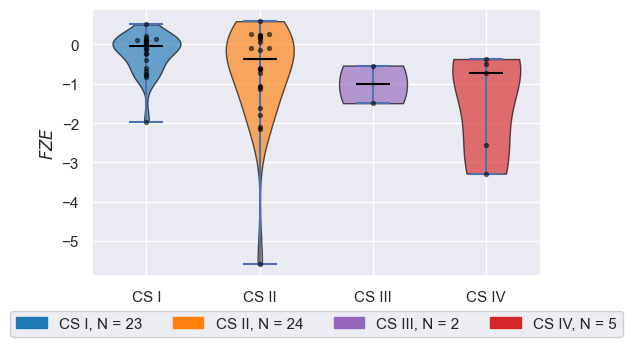

In [237]:
x = (["CS I", "CS II", "CS III", "CS IV"], [1, 2, 3, 4])
fig, ax = plt.subplots(figsize=(418.25368 / 72.27, 418.25368 / 72.27 * 0.6))

cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red"]
patches = []
for color, label in zip(cs_colors, x[0]):
    data = pick_data(label, "pH")    
    patches.append(mpatches.Patch(color=color, label=f"{label}, N = {len(data)}"))

def style_violins(parts, colors):
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.65)
    if "cmedians" in parts:
        parts["cmedians"].set_color("black")

data = [
    csi_ph["FZE"],
    csii_ph["FZE"],
    csiii_ph["FZE"],
    csiv_ph["FZE"],
]
positions = [1, 2, 3, 4]

parts2 = ax.violinplot(data, positions=positions, showmedians=True, widths=0.6)
style_violins(parts2, cs_colors)

for pos, values in zip(positions, data):
    x_vals = jitter_by_proximity(values, pos, max_width=0.08, threshold=0.005)
    ax.scatter(x_vals, values, color="black", s=8, alpha=0.5, zorder=3)

ax.set_ylabel("$FZE$")
ax.set_xticks(positions)
ax.set_xticklabels(x[0])
ax.legend(
    handles=patches,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    framealpha=0.9,
    ncol=4,
    bbox_transform=ax.transAxes,
)


fig.savefig("../images/ph_violins", dpi = 300, bbox_inches = "tight")

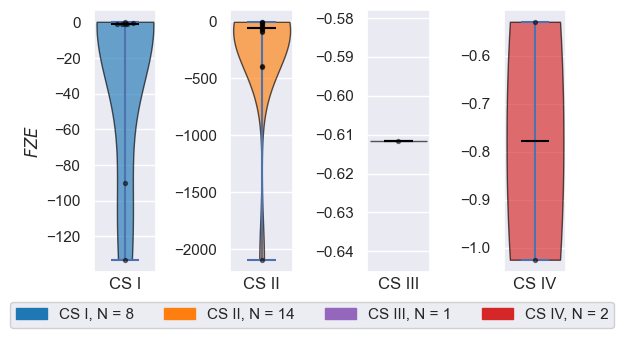

In [238]:
textwidth_in = 418.25368 / 72.27
fig, axes = plt.subplots(1, 4, figsize=(textwidth_in, textwidth_in * 0.55),
                         sharey=False)

cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red"]
cs_labels  = ["CS I", "CS II", "CS III", "CS IV"]
data = [csi_fe_dis["FZE"], csii_fe_dis["FZE"], csiii_fe_dis["FZE"], csiv_fe_dis["FZE"]]
patches = []
for color, label in zip(cs_colors, x[0]):
    d = pick_data(label, "Fe-Dis")    
    patches.append(mpatches.Patch(color=color, label=f"{label}, N = {len(d)}"))
    
for ax, vals, color, label in zip(axes, data, cs_colors, cs_labels):
    clean_vals = vals.dropna()
    parts = ax.violinplot(clean_vals, positions=[1], widths=0.6, showmedians=True)

    for body in parts["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.65)
    parts["cmedians"].set_color("black")

    x_points = jitter_by_proximity(clean_vals.values, center=1, max_width=0.08, threshold=0.08)
    ax.scatter(x_points, clean_vals, color="black", s=8, alpha=0.5, zorder=3)

    ax.set_xticks([])
    ax.set_xlabel(label)
    if ax == axes[0]:
        ax.set_ylabel("$FZE$")
fig.legend(
    handles=patches,
    loc="lower center",
    bbox_to_anchor=(0.53, -0.08),
    bbox_transform=fig.transFigure,
    framealpha=0.9,
    ncol=4,
)
fig.subplots_adjust(bottom=0.18)
fig.tight_layout()
fig.savefig("../images/iron_violins.png", dpi=300, bbox_inches="tight")

<h2>Pollution plume plots

In [10]:
def get_var_from_amd(vars):
    csi_amd = xr.open_dataset("../data/validation data/AMDFLOW_CSI_1960-2015_W.nc")
    csi_var = csi_amd[vars[0]]
    csi_amd.close()

    csii_amd = xr.open_dataset("../data/validation data/AMDFLOW_CSII_1960-2015_W.nc")
    csii_var = csii_amd[vars[1]]
    csii_amd.close()

    csiii_amd = xr.open_dataset("../data/validation data/AMDFLOW_CSIII_1960-2015_W.nc")
    csiii_var = csiii_amd[vars[2]]
    csiii_amd.close()

    csiv_amd = xr.open_dataset("../data/validation data/AMDFLOW_CSIV_1960-2015_W.nc")
    csiv_var = csiv_amd[vars[3]]
    csiv_amd.close()
    return csi_var, csii_var, csiii_var, csiv_var

In [14]:
vars = ["ferric_iron", "ferrous_iron", "ferric_oxyhydroxide", "bedload_storage"]
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

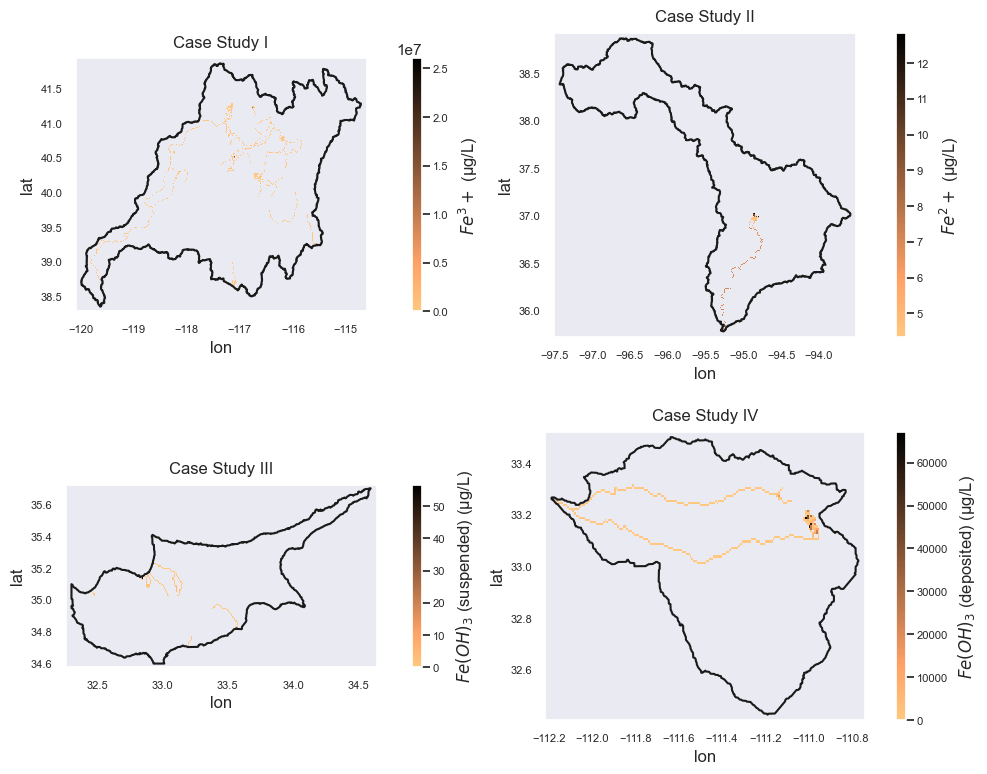

In [124]:
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

bar_vars = [
    "$Fe^3+$",
    "$Fe^2+$",
    "$Fe(OH)_3$ (suspended)",
    "$Fe(OH)_3$ (deposited)",
]
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()
fig.savefig("../images/plumes.png", dpi = 300, bbox_inches="tight")


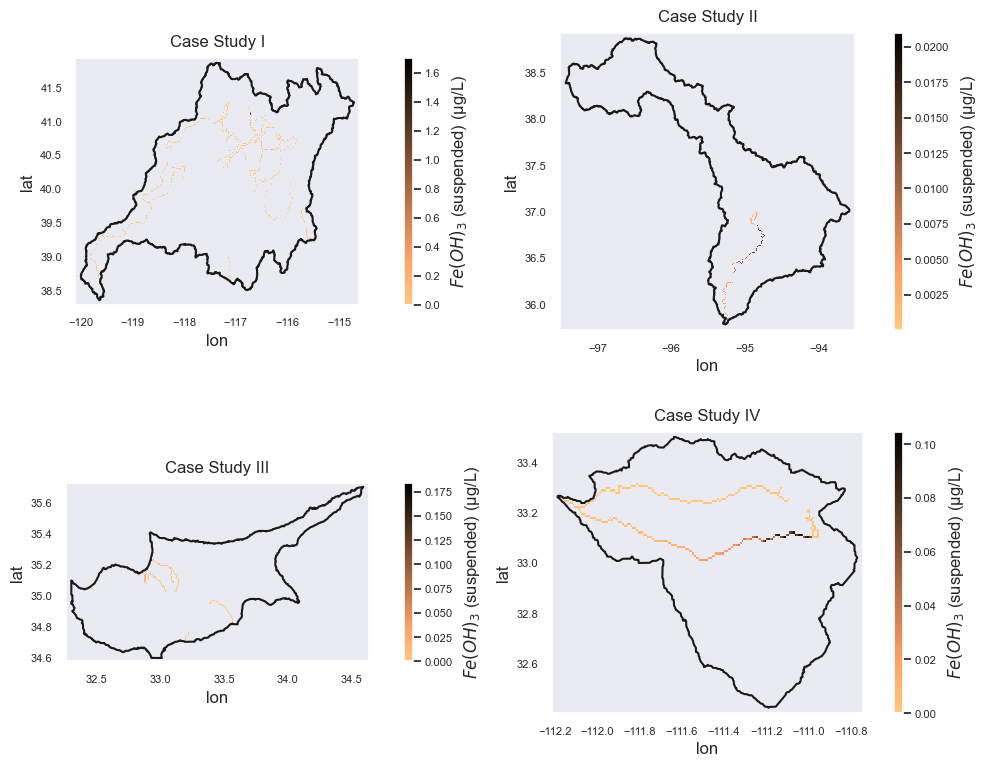

In [125]:
vars = ["ferric_oxyhydroxide", "ferric_oxyhydroxide", "ferric_oxyhydroxide", "ferric_oxyhydroxide"]
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$Fe(OH)_3$ (suspended)",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

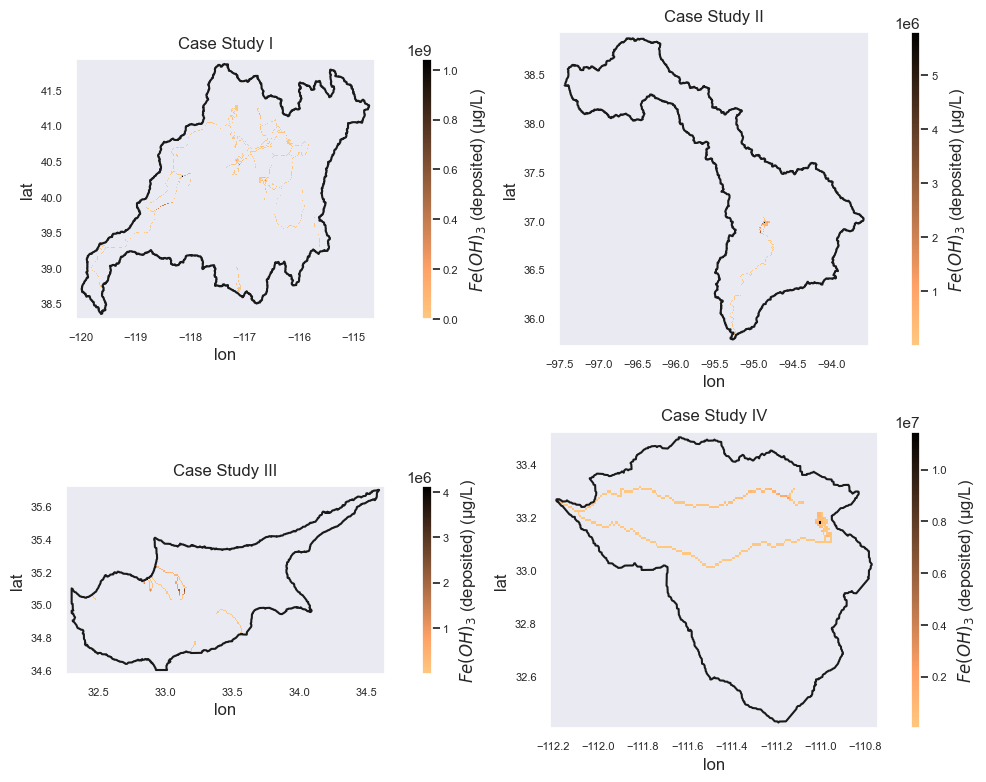

In [126]:
vars = ["bedload_storage"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$Fe(OH)_3$ (deposited)",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

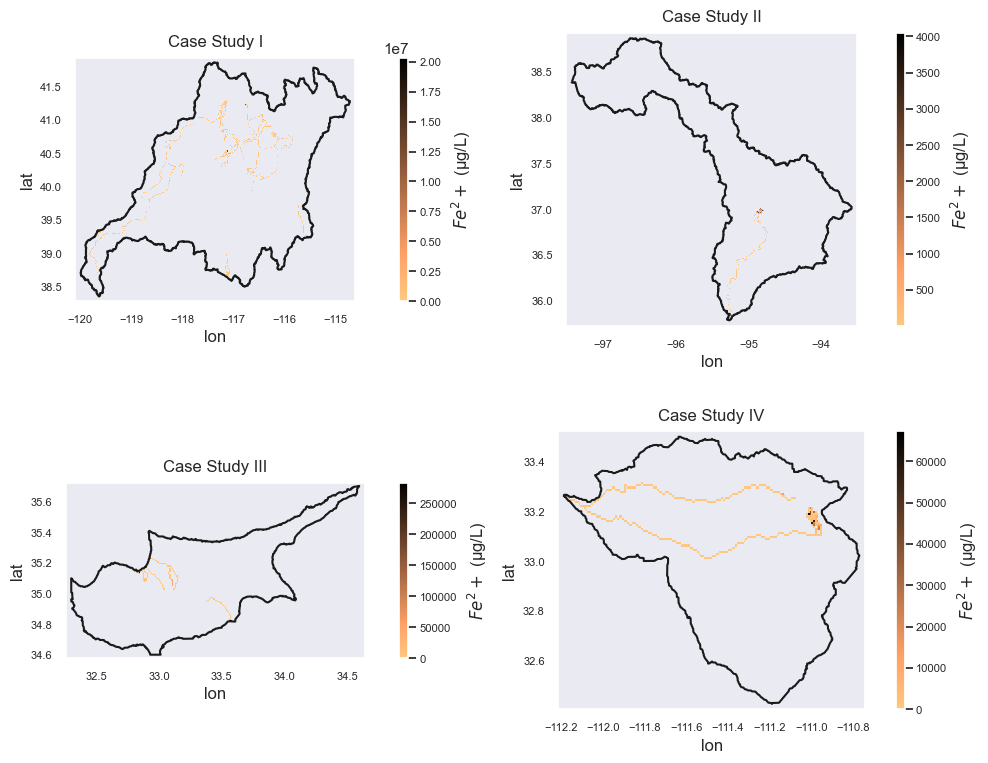

In [127]:
vars = ["ferrous_iron"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$Fe^2+$",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

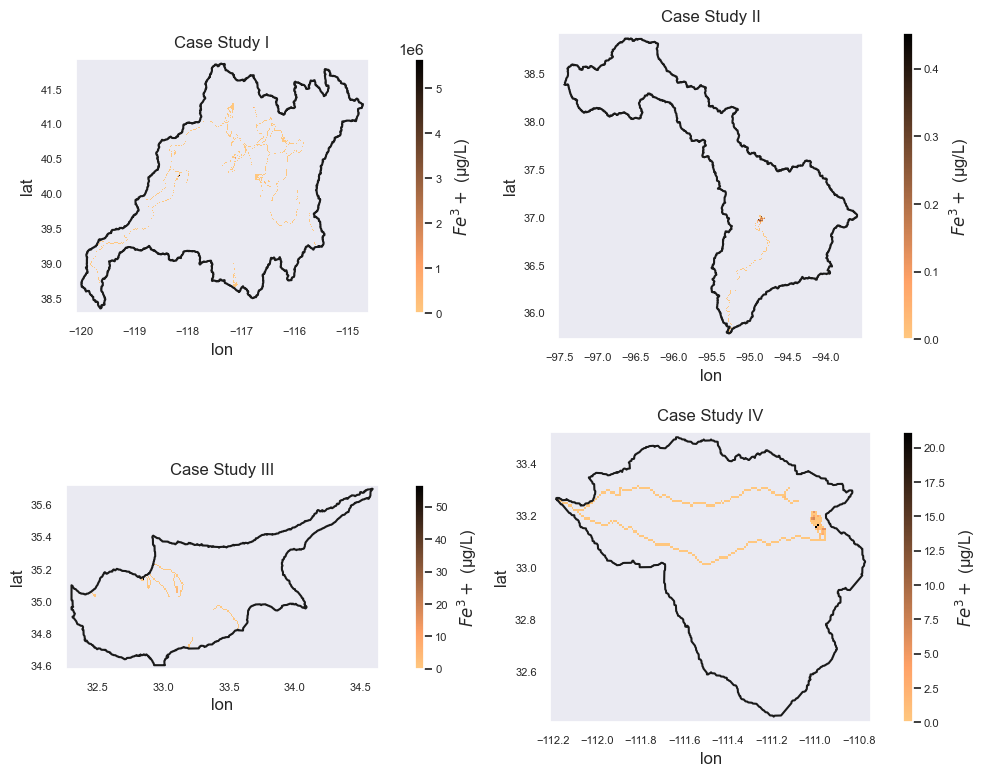

In [128]:
vars = ["ferric_iron"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$Fe^3+$",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

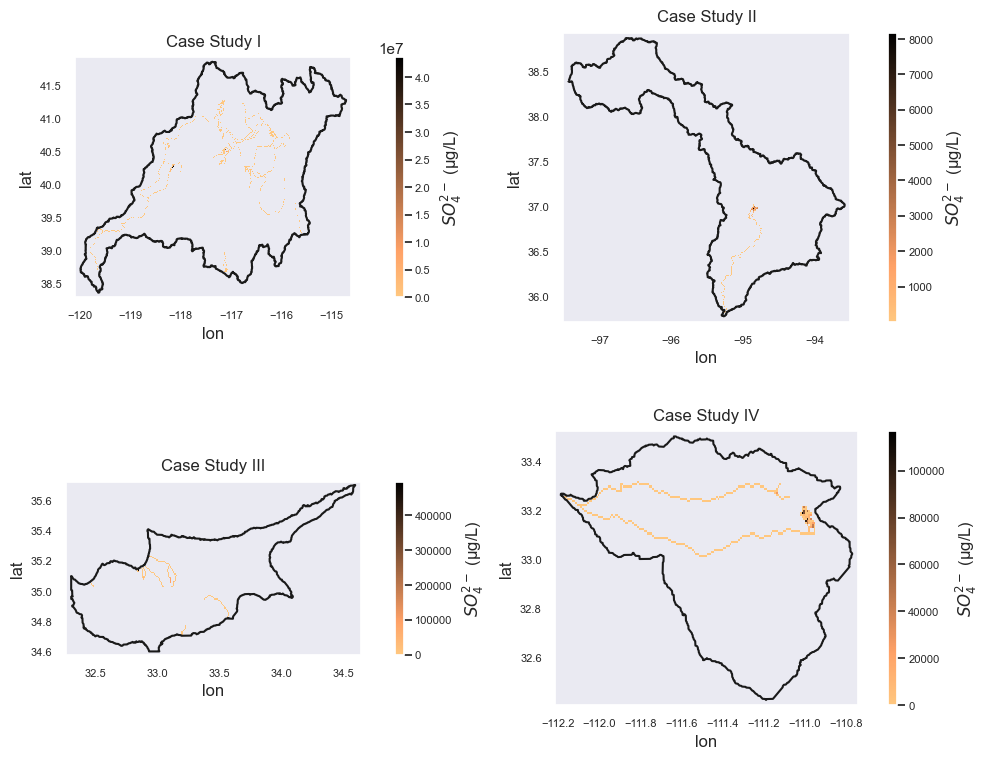

In [129]:
vars = ["sulphate"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "$SO_{4}^{2-}$",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

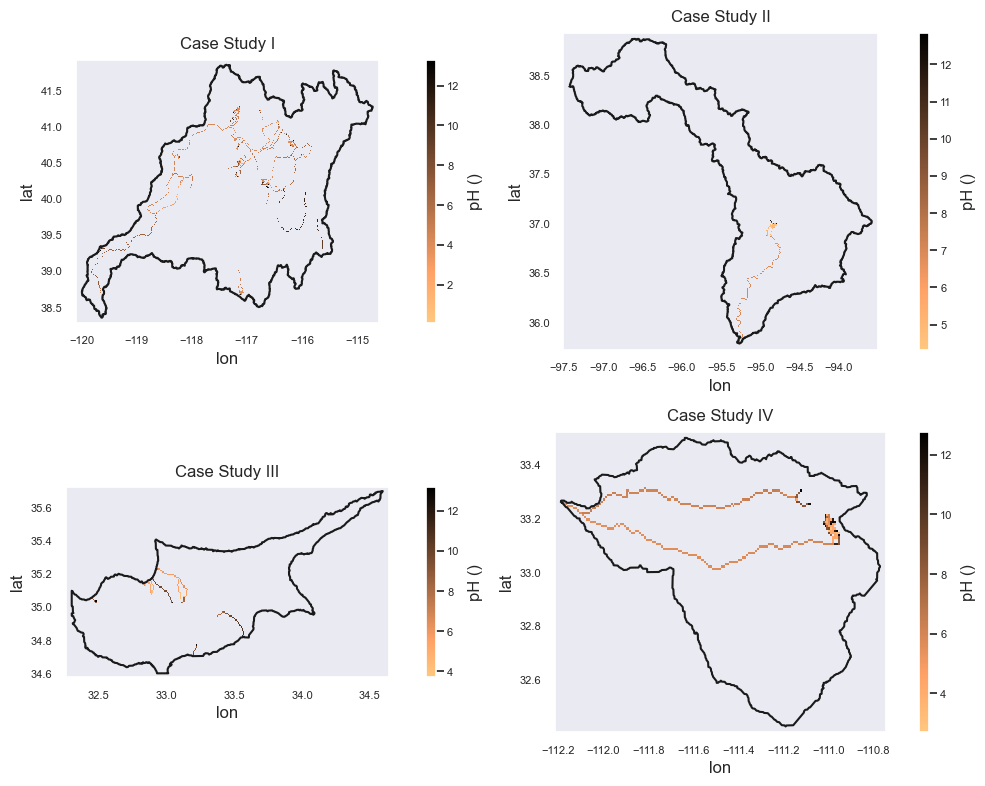

In [130]:
vars = ["pH"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

bar_vars = [
    "pH",
] * 4
units = [""] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    cb = fig.colorbar(mesh, cax=cax)
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()

<h2>WQMS position plot

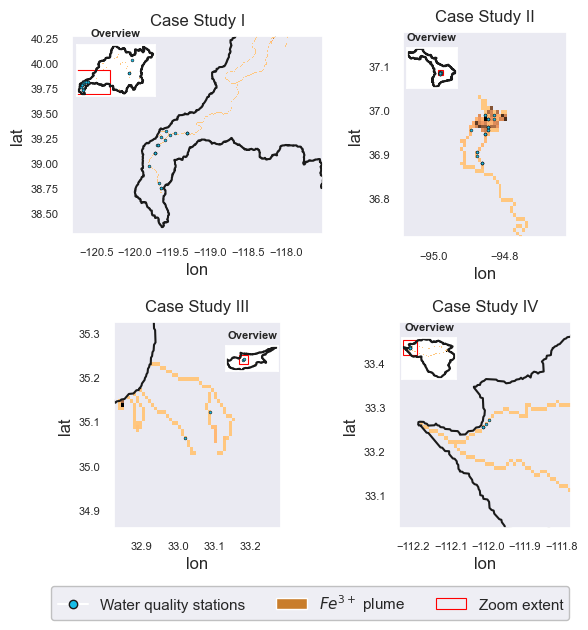

In [244]:
vars = ["ferric_iron"] * 4
csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(vars)

ph_dfs = [csi_ph, csii_ph, csiii_ph, csiv_ph]
fe_dfs = [csi_fe_dis, csii_fe_dis, csiii_fe_dis, csiv_fe_dis]

bar_vars = [
    "$Fe^3+$",
] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(textwidth_in * 1.1, textwidth_in * 1.1))
axes = axs.flatten()
vars_ = [csi_var, csii_var, csiii_var, csiv_var]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

inset_positions = {
    "Case Study I":   [0.67, 0.67, 0.31, 0.31],  # upper right
    "Case Study II":  [0.02, 0.67, 0.31, 0.31],  # upper left
    "Case Study III": [0.67, 0.02, 0.31, 0.31],  # lower right
    "Case Study IV":  [0.02, 0.02, 0.31, 0.31],  # lower left
}

inset_positions = {
    "Case Study I":   [0.02, 0.67, 0.31, 0.31],  
    "Case Study II":  [0.02, 0.67, 0.31, 0.31],  
    "Case Study III": [0.67, 0.67, 0.31, 0.31],  
    "Case Study IV":  [0.02, 0.67, 0.31, 0.31],  
}


def add_station_markers(ax, ph_df, fe_df):
    ph_df = ph_df.dropna(subset=["cell_lat", "cell_lon"])
    fe_df = fe_df.dropna(subset=["cell_lat", "cell_lon"])

    if ph_df.empty and fe_df.empty:
        return

    station_coords = []
    for station_id in sorted(set(ph_df["wqms_id"].astype(str)) | set(fe_df["wqms_id"].astype(str))):
        coord_df = ph_df.loc[ph_df["wqms_id"].astype(str) == station_id, ["cell_lat", "cell_lon"]]
        if coord_df.empty:
            coord_df = fe_df.loc[fe_df["wqms_id"].astype(str) == station_id, ["cell_lat", "cell_lon"]]
        if coord_df.empty:
            continue

        row = coord_df.iloc[0]
        station_coords.append((float(row["cell_lon"]), float(row["cell_lat"])))
        ax.scatter(
            row["cell_lon"], row["cell_lat"],
            s=4,
            c="#15BDE8",
            marker="o",
            edgecolor="k",
            linewidth=0.4,
            zorder=3,
        )

    return station_coords


def get_zoom_window(station_coords):
    if len(station_coords) == 0:
        return None

    lons = np.array([lon for lon, _ in station_coords])
    lats = np.array([lat for _, lat in station_coords])

    lon_center = lons.mean()
    lat_center = lats.mean()
    lon_span = max((lons.max() - lons.min()) / 2.5, 0.2)
    lat_span = max((lats.max() - lats.min()) / 2.5, 0.2)

    return (
        lon_center - lon_span,
        lon_center + lon_span,
        lat_center - lat_span,
        lat_center + lat_span,
    )

def best_inset_corner(station_coords, xlim, ylim):
    corners = {
        "upper_right": [0.67, 0.67, 0.31, 0.31],
        "upper_left":[0.02, 0.67, 0.31, 0.31],
        "lower_right": [0.67, 0.02, 0.31, 0.31],
        "lower_left": [0.02, 0.02, 0.31, 0.31],
    }
    if not station_coords:
        return corners["upper_right"]
    lons = np.array([c[0] for c in station_coords])
    lats = np.array([c[1] for c in station_coords])
    xmid = (xlim[0] + xlim[1]) / 2
    ymid = (ylim[0] + ylim[1]) / 2
    counts = {
        "upper_right": np.sum((lons >= xmid) & (lats >= ymid)),
        "upper_left": np.sum((lons <  xmid) & (lats >= ymid)),
        "lower_right": np.sum((lons >= xmid) & (lats <  ymid)),
        "lower_left": np.sum((lons <  xmid) & (lats <  ymid)),
    }
    return corners[min(counts, key=counts.get)]

for ax, var, bar_title, unit, aoi, plot_title, ph_df, fe_df in zip(
    axes, vars_, bar_vars, units, aois, titles, ph_dfs, fe_dfs
):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    arr.plot(ax=ax, add_colorbar=False, cmap="copper_r")

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")
    station_coords = add_station_markers(ax, ph_df, fe_df)

    bounds = aoi.total_bounds
    dx = bounds[2] - bounds[0]
    dy = bounds[3] - bounds[1]
    pad = 0.02
    ax.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
    ax.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)

    zoom_window = get_zoom_window(station_coords)
    if zoom_window is not None:
        lon_min, lon_max, lat_min, lat_max = zoom_window
        span_lon = lon_max - lon_min
        span_lat = lat_max - lat_min
        pad_lon = span_lon * 0.08
        pad_lat = span_lat * 0.08
        xl = (lon_min - pad_lon, lon_max + pad_lon)
        yl = (lat_min - pad_lat, lat_max + pad_lat)
        ax.set_xlim(*xl)
        ax.set_ylim(*yl)


        inset_pos = inset_positions[plot_title]
        ax_zoom = ax.inset_axes(inset_pos)
        ax_zoom.set_facecolor("white")
        arr.plot(ax=ax_zoom, add_colorbar=False, cmap="copper_r")
        aoi.boundary.plot(ax=ax_zoom, edgecolor="k")
        add_station_markers(ax_zoom, ph_df, fe_df)
        ax_zoom.set_xlim(bounds[0] - dx * pad, bounds[2] + dx * pad)
        ax_zoom.set_ylim(bounds[1] - dy * pad, bounds[3] + dy * pad)
        ax_zoom.set_xticks([])
        ax_zoom.set_yticks([])
        ax_zoom.set_xlabel("")
        ax_zoom.set_ylabel("")
        ax_zoom.set_title("Overview", fontsize=8, fontdict={"fontweight": "bold"})
        ax_zoom.set_aspect("equal")
        ax_zoom.add_patch(
            mpatches.Rectangle(
                (lon_min, lat_min),
                span_lon,
                span_lat,
                fill=False,
                edgecolor="red",
                linewidth=0.8,
            )
        )

station_handle = plt.Line2D(
    [0], [0], marker="o", color="w", label="Water quality stations",
    markerfacecolor="#15BDE8", markeredgecolor="k", markersize=6
)
plume_handle = mpatches.Patch(         
    facecolor="#c97d2b", label="$Fe^{3+}$ plume",
)

zoom_handle = mpatches.Rectangle(         
    (0, 0), 1, 1,
    fill=False, edgecolor="red", linewidth=0.8,
    label="Zoom extent",
)

fig.legend(
    handles=[station_handle, plume_handle, zoom_handle],   
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=3,                   
    frameon=True,
    edgecolor="0.7",
)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.12, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("../images/validation_maps.png", dpi = 300, bbox_inches = "tight")

<h2>Mindat data plot

Loaded Natural Earth 110 m geometry  (column: ISO_A3_EH)

Matched 126 / 129 countries with localities to geometry.

Saved PNG  → ../images/pyrite_map.png  (300 dpi)


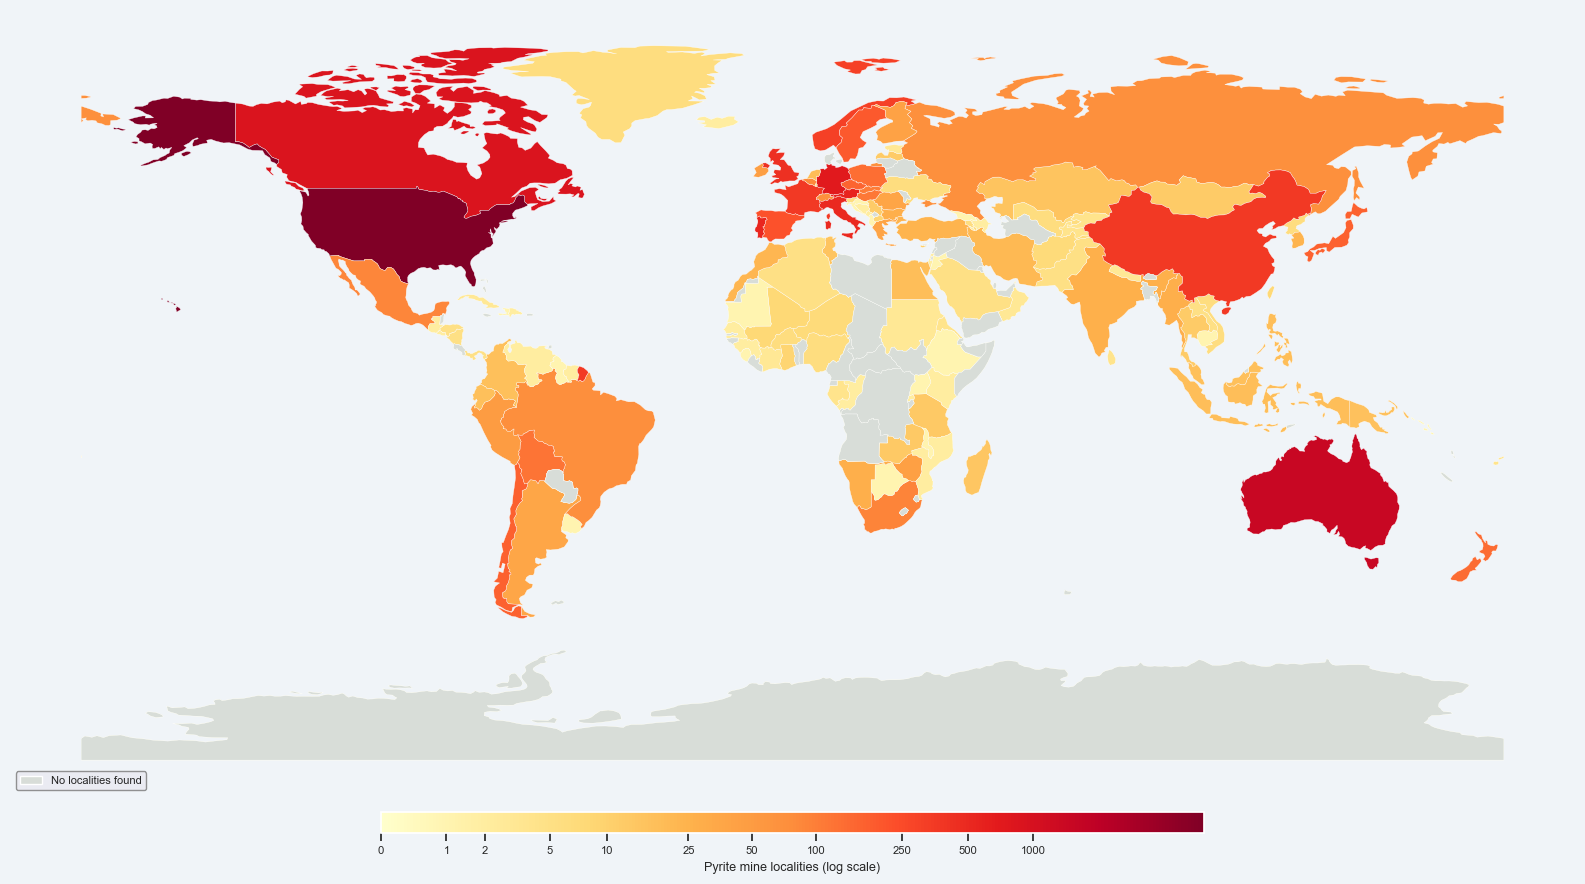

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import geopandas as gpd
warnings.filterwarnings("ignore", category=DeprecationWarning)

def load_summary(csv_path: str = "../data/mindat_data/summary.csv"):
    df = pd.read_csv(csv_path)
    df["count"] = df["count"].clip(lower=0)
    return df[["iso3", "country", "count"]]

def load_world():
    """Returns (world_geodataframe, iso_column_name)."""
    NE_URL = (
        "https://naturalearth.s3.amazonaws.com/110m_cultural/"
        "ne_110m_admin_0_countries.zip"
    )
    try:
        world = gpd.read_file(NE_URL)
        iso_col = "ISO_A3_EH" if "ISO_A3_EH" in world.columns else "ISO_A3"
        print(f"Loaded Natural Earth 110 m geometry  (column: {iso_col})")
        return world, iso_col

    except Exception as exc:
        print(f"Could not fetch 110 m file ({exc}); falling back to bundled data.")
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    print("Loaded bundled naturalearth_lowres geometry  (column: iso_a3)")
    return world, "iso_a3"


def merge_data(
    world: gpd.GeoDataFrame,
    iso_col: str,
    summary: pd.DataFrame,
):
    """
    Left-join world geometry with summary counts on the ISO-alpha3 code.
    Countries with no match (Antarctica, disputed territories, …) get count=0.
    """
    merged = world.merge(
        summary[["iso3", "count"]],
        left_on=iso_col,
        right_on="iso3",
        how="left",
    )
    merged["count"] = merged["count"].fillna(0).astype(int)
    return merged


def plot_static_map(
    merged: gpd.GeoDataFrame,
    log_scale: bool = True,
    output_png: str  = "../images/pyrite_map.png",
    dpi: int  = 300,
):
    """Saves a static choropleth world map."""
    fig, ax = plt.subplots(figsize=(18, 9), facecolor="#f0f4f8")
    ax.set_facecolor("#d6e8f5")          # ocean colour

    cmap = mpl.colormaps["YlOrRd"]

    if log_scale:
        merged["_c"] = np.log10(merged["count"] + 1)
    else:
        merged["_c"] = merged["count"].astype(float)

    vmin, vmax = 0.0, merged["_c"].max()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)


    merged.plot(
        column="_c",
        cmap=cmap,
        norm=norm,
        ax=ax,
        edgecolor="white",
        linewidth=0.25,
        missing_kwds={"color": "#c8d6c8", "label": "No data"},  # fallback
    )


    zero_mask = merged["count"] == 0
    merged[zero_mask].plot(
        ax=ax,
        color="#d8ddd8",
        edgecolor="white",
        linewidth=0.25,
    )

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm, ax=ax,
        orientation="horizontal",
        fraction=0.025,
        pad=0.02,
        aspect=40,
    )

    if log_scale:
        raw_ticks = [0, 1, 2, 5, 10, 25, 50, 100, 250, 500, 1000]
        max_raw = int(10 ** vmax - 1)
        raw_ticks = [t for t in raw_ticks if t <= max_raw]
        log_ticks = [np.log10(t + 1) for t in raw_ticks]

        cbar.set_ticks(log_ticks)
        cbar.set_ticklabels([str(t) for t in raw_ticks], fontsize=8)
        cbar.set_label("Pyrite mine localities (log scale)", fontsize=9)
    else:
        cbar.set_label("Pyrite mine localities", fontsize=9)

    ax.set_axis_off()

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#d8ddd8", edgecolor="white", label="No localities found"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="lower left",
        fontsize=8,
        framealpha=0.85,
        edgecolor="grey",
    )

    plt.tight_layout()

    if output_png:
        fig.savefig(output_png, dpi=dpi, bbox_inches="tight")
        print(f"Saved PNG  → {output_png}  ({dpi} dpi)")

    plt.show()
    plt.close(fig)




summary = load_summary("../data/mindat_data/summary.csv")
world, iso_col = load_world()
merged = merge_data(world, iso_col, summary)

n_matched = (merged["count"] > 0).sum()
n_total = len(summary[summary["count"] > 0])
print(f"\nMatched {n_matched} / {n_total} countries with localities to geometry.\n")

plot_static_map(
    merged,
    log_scale=True,
    output_png="../images/pyrite_map.png",
    dpi=300,
)

<h2>Analytical vs. numerical solution plot

In [22]:
K2_OX = 2.91e-9
K1_OX = 1.33e12
PO2 = 0.21
KW = 1e-14

def oxidation_lambda(h_plus, pO2=PO2):
    """H+ in mol/L, Po2 constant."""
    oh = KW / h_plus
    return (K2_OX + K1_OX * oh * oh) * pO2

def fe2_analytical(t, fe2_0, h_plus, pO2=PO2):
    lam = oxidation_lambda(h_plus, pO2)
    return fe2_0 * np.exp(-lam * t)

def integrate_fe2_coupled(fe2_0, fe3_0, h_plus_0, t_end, n_steps=1000, pO2=PO2):
    t = np.linspace(0.0, t_end, n_steps)
    fe2 = np.empty_like(t)
    fe3 = np.empty_like(t)
    h = np.empty_like(t)

    fe2[0] = fe2_0
    fe3[0] = fe3_0
    h[0] = h_plus_0

    for i in range(1, n_steps):
        dt = t[i] - t[i-1]
        lam = oxidation_lambda(h[i-1], pO2)
        r = lam * fe2[i-1]
        fe2[i] = max(fe2[i-1] - r * dt, 0.0)
        fe3[i] = fe3[i-1] + r * dt
        h[i] = max(h[i-1] - r * dt, 1e-20)

    return t, fe2, fe3, h
    

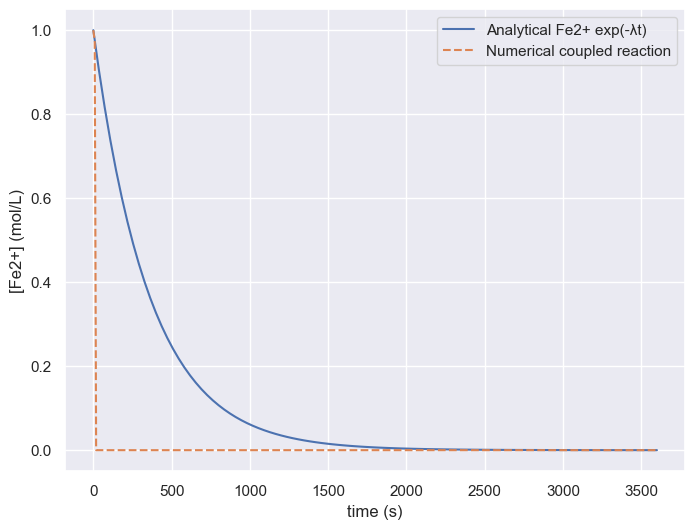

In [ ]:
fe2_0 = 1.0      
fe3_0 = 0.0
h_plus_0 = 1e-7   
t_end = 3600.0  # seconds
t = np.linspace(0, t_end, 100)

fe2_ana = fe2_analytical(t, fe2_0, h_plus_0)
t_num, fe2_num, fe3_num, h_num = integrate_fe2_coupled(
    fe2_0, fe3_0, h_plus_0, t_end, n_steps=400
)

plt.figure(figsize=(8, 6))
plt.plot(t, fe2_ana, label="Analytical Fe2+ exp(-λt)")
plt.plot(t_num, fe2_num, "--", label="Numerical coupled reaction")
plt.xlabel("time (s)")
plt.ylabel("[Fe2+] (mol/L)")
plt.legend()
plt.grid(True)
plt.show()


<h2>FZE histograms

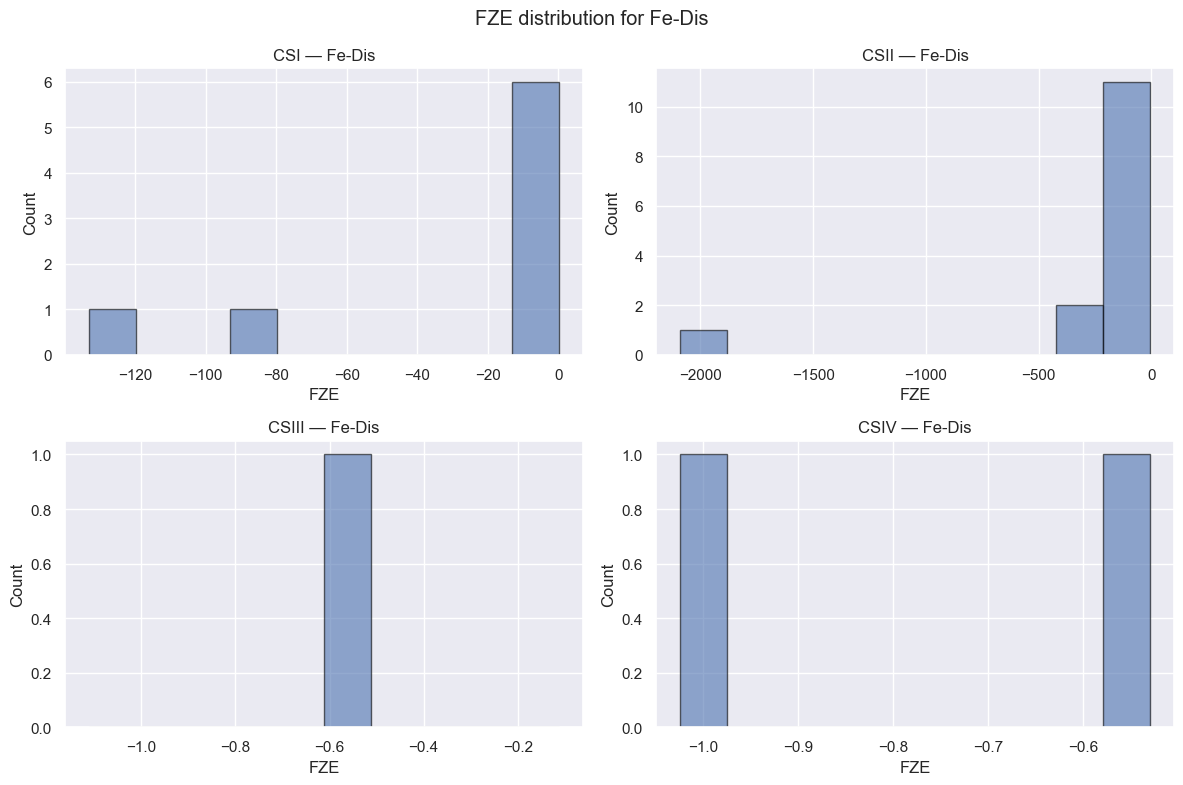

In [ ]:
selected_var = "Fe-Dis"  

frame_map = {
    "pH": {
        "CSI": csi_ph,
        "CSII": csii_ph,
        "CSIII": csiii_ph,
        "CSIV": csiv_ph,
    },
    "Fe-Dis": {
        "CSI": csi_fe_dis,
        "CSII": csii_fe_dis,
        "CSIII": csiii_fe_dis,
        "CSIV": csiv_fe_dis,
    },
}

if selected_var not in frame_map:
    raise ValueError(f"selected_var must be one of {list(frame_map.keys())}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, (case_name, df) in zip(axes, frame_map[selected_var].items()):
    fze_vals = pd.to_numeric(df["FZE"], errors="coerce").dropna()
    if not fze_vals.empty:
        ax.hist(fze_vals, bins=10, alpha=0.6, edgecolor="black")
    ax.set_title(f"{case_name} — {selected_var}")
    ax.set_xlabel("FZE")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

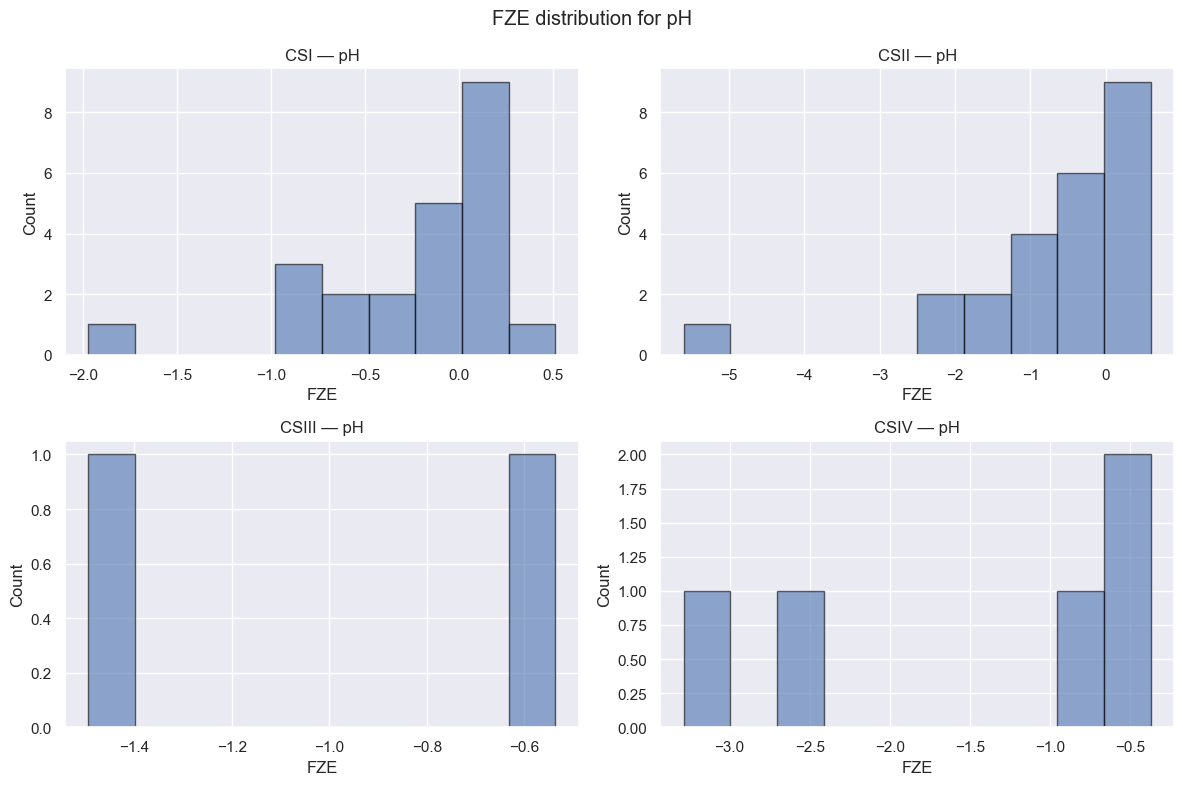

In [ ]:
selected_var = "pH"  

frame_map = {
    "pH": {
        "CSI": csi_ph,
        "CSII": csii_ph,
        "CSIII": csiii_ph,
        "CSIV": csiv_ph,
    },
    "Fe-Dis": {
        "CSI": csi_fe_dis,
        "CSII": csii_fe_dis,
        "CSIII": csiii_fe_dis,
        "CSIV": csiv_fe_dis,
    },
}

if selected_var not in frame_map:
    raise ValueError(f"selected_var must be one of {list(frame_map.keys())}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, (case_name, df) in zip(axes, frame_map[selected_var].items()):
    fze_vals = pd.to_numeric(df["FZE"], errors="coerce").dropna()
    if not fze_vals.empty:
        ax.hist(fze_vals, bins=10, alpha=0.6, edgecolor="black")
    ax.set_title(f"{case_name} — {selected_var}")
    ax.set_xlabel("FZE")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

<h2>Time series plots

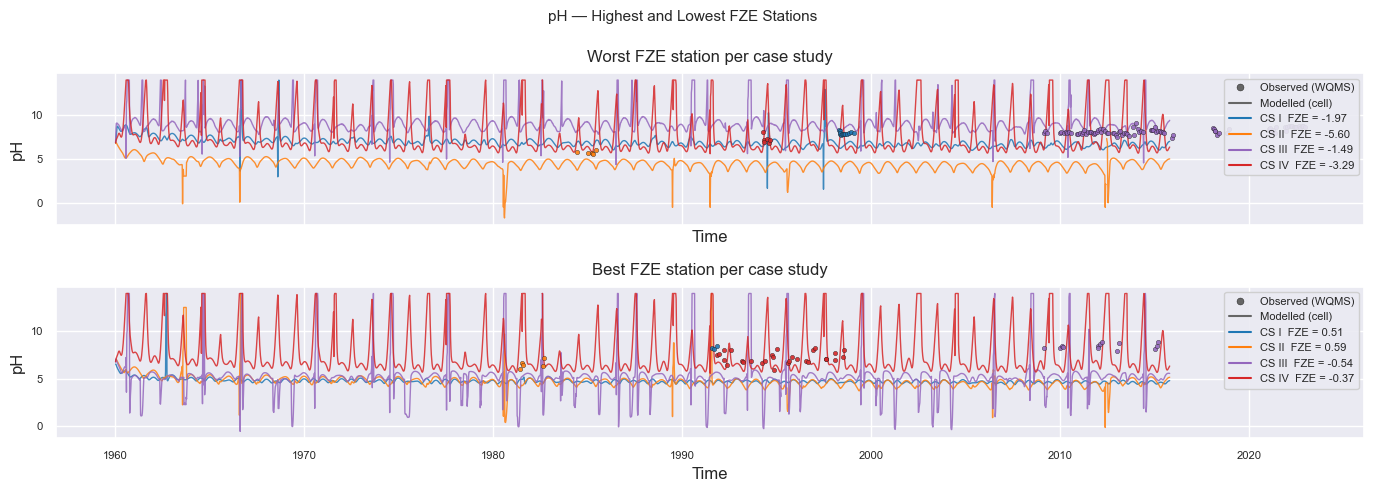

In [90]:
import matplotlib.lines as mlines
cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red"]
cs_labels  = ["CS I", "CS II", "CS III", "CS IV"]
fze_col    = "FZE"

ph_dfs = [csi_ph, csii_ph, csiii_ph, csiv_ph]

csi_var, csii_var, csiii_var, csiv_var = get_var_from_amd(["pH"] * 4)
cs_vars = [csi_var, csii_var, csiii_var, csiv_var]

caravan = xr.open_dataset(caravan_path, engine="zarr", chunks={})

def pick_station(ph_df, mode):
    """Row with the best or worst FZE score."""
    idx = ph_df[fze_col].idxmin() if mode == "worst" else ph_df[fze_col].idxmax()
    return ph_df.loc[idx]

def modelled_ts(var, cell_lat, cell_lon):
    """Nearest-cell time series from the raster DataArray."""
    lat_dim = "lat" if "lat" in var.dims else "y"
    lon_dim = "lon" if "lon" in var.dims else "x"
    return var.sel({lat_dim: cell_lat, lon_dim: cell_lon}, method="nearest")

def observed_ts(wqms_id):
    return caravan["pH"].sel(wqms_id=wqms_id)


fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex = True)

for ax, mode in zip(axes, ["worst", "best"]):
    cs_handles = []

    for ph_df, var, color, cs_label in zip(ph_dfs, cs_vars, cs_colors, cs_labels):
        row       = pick_station(ph_df, mode)
        wqms_id   = row["wqms_id"]
        cell_lat  = float(row["cell_lat"])
        cell_lon  = float(row["cell_lon"])
        fze_score = float(row[fze_col])

        mod = modelled_ts(var, cell_lat, cell_lon)
        obs = observed_ts(wqms_id)

        
        ax.plot(
            mod.time.values, mod.values,
            color=color, linewidth=1.0, alpha=0.85,
        )
        
        ax.scatter(
            obs.time.values, obs.values,
            color=color, s=10, alpha=0.9,
            edgecolors="k", linewidths=0.3, zorder=3,
        )

        cs_handles.append(mlines.Line2D(
            [], [], color=color, linewidth=1.5,
            label=f"{cs_label}  FZE = {fze_score:.2f}",
        ))

    obs_handle = mlines.Line2D(
        [], [], marker="o", linestyle="None", color="0.4",
        markeredgecolor="k", markeredgewidth=0.3, markersize=5,
        label="Observed (WQMS)",
    )
    mod_handle = mlines.Line2D(
        [], [], color="0.4", linewidth=1.5,
        label="Modelled (cell)",
    )

    ax.legend(handles=[obs_handle, mod_handle, *cs_handles], fontsize=8, framealpha=0.9)
    ax.set_title(f"{'Worst' if mode == 'worst' else 'Best'} FZE station per case study", pad=8)
    ax.set_xlabel("Time")
    ax.set_ylabel("pH")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("pH — Highest and Lowest FZE Stations", fontsize=11)
fig.tight_layout()
fig.savefig("../images/ph_best_worst_fze.png", dpi=300, bbox_inches="tight")

In [ ]:

cs_color = "tab:orange"
cs_label = "CS II"
fze_col  = "FZE" 

_, csii_var, _, _ = get_var_from_amd(["pH"] * 4)
caravan = xr.open_dataset(caravan_path, engine="zarr", chunks={})


def pick_station(ph_df, mode):
    idx = ph_df[fze_col].idxmin() if mode == "worst" else ph_df[fze_col].idxmax()
    return ph_df.loc[idx]

def modelled_ts(var, cell_lat, cell_lon):
    lat_dim = "lat" if "lat" in var.dims else "y"
    lon_dim = "lon" if "lon" in var.dims else "x"
    return var.sel({lat_dim: cell_lat, lon_dim: cell_lon}, method="nearest")

def observed_ts(wqms_id, var_name):
    return caravan[var_name].sel(wqms_id=wqms_id)


pH — Best and Worst Performing Station (CS II)


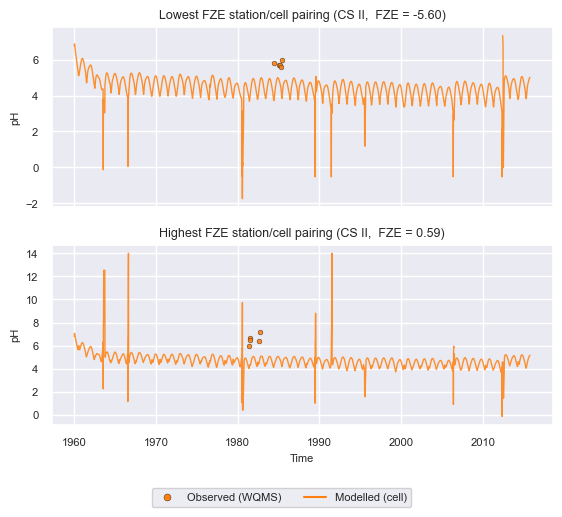

In [109]:
textwidth_in = 418.25368 / 72.27   

fig, axes = plt.subplots(2, 1, figsize=(textwidth_in, textwidth_in * 0.9), sharex=True)


obs_handle = mlines.Line2D(
    [], [], marker="o", linestyle="None", color=cs_color,
    markeredgecolor="k", markeredgewidth=0.3, markersize=5,
    label="Observed (WQMS)",
)
mod_handle = mlines.Line2D(
    [], [], color=cs_color, linewidth=1.5,
    label="Modelled (cell)",
)

for ax, mode in zip(axes, ["worst", "best"]):
    row       = pick_station(csii_ph, mode)
    wqms_id   = row["wqms_id"]
    cell_lat  = float(row["cell_lat"])
    cell_lon  = float(row["cell_lon"])
    fze_score = float(row[fze_col])

    mod = modelled_ts(csii_var, cell_lat, cell_lon)
    obs = observed_ts(wqms_id, "pH")

    ax.plot(mod.time.values, mod.values, color=cs_color, linewidth=1.0, alpha=0.85)
    ax.scatter(
        obs.time.values, obs.values,
        color=cs_color, s=12, alpha=0.9,
        edgecolors="k", linewidths=0.3, zorder=3,
    )

    ax.set_title(
        f"{'Lowest' if mode == 'worst' else 'Highest'} FZE station/cell pairing "
        f"({cs_label},  FZE = {fze_score:.2f})",
        pad=6, fontsize=9,
    )
    ax.set_ylabel("pH", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)

axes[-1].set_xlabel("Time", fontsize=8)

fig.legend(
    handles=[obs_handle, mod_handle],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=2,
    fontsize=8,
    framealpha=0.9,
)

print(f"pH — Best and Worst Performing Station ({cs_label})")
fig.tight_layout(rect=[0, 0.06, 1, 1])  
fig.savefig("../images/ph_best_worst_fze_csii.png", dpi=300, bbox_inches="tight")

pH — Best and Worst Performing Station (CS I)


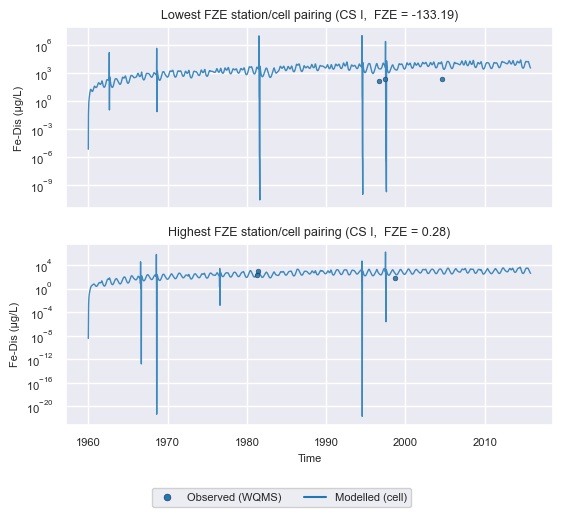

In [116]:
cs_color = "tab:blue"
cs_label = "CS I"
fze_col  = "FZE"   

csi_var_f2, _, _, _ = get_var_from_amd(["ferrous_iron"] * 4)
csi_var_f3, _, _, _ = get_var_from_amd(["ferric_iron"] * 4)

csi_var = csi_var_f2 + csi_var_f3

caravan = xr.open_dataset(caravan_path, engine="zarr", chunks={})
fig, axes = plt.subplots(2, 1, figsize=(textwidth_in, textwidth_in * 0.9), sharex=True)


obs_handle = mlines.Line2D(
    [], [], marker="o", linestyle="None", color=cs_color,
    markeredgecolor="k", markeredgewidth=0.3, markersize=5,
    label="Observed (WQMS)",
)
mod_handle = mlines.Line2D(
    [], [], color=cs_color, linewidth=1.5,
    label="Modelled (cell)",
)

for ax, mode in zip(axes, ["worst", "best"]):
    row       = pick_station(csi_fe_dis, mode)
    wqms_id   = row["wqms_id"]
    cell_lat  = float(row["cell_lat"])
    cell_lon  = float(row["cell_lon"])
    fze_score = float(row[fze_col])

    mod = modelled_ts(csi_var, cell_lat, cell_lon)
    obs = observed_ts(wqms_id, "Fe-Dis")

    ax.plot(mod.time.values, mod.values, color=cs_color, linewidth=1.0, alpha=0.85)
    ax.scatter(
        obs.time.values, obs.values,
        color=cs_color, s=12, alpha=0.9,
        edgecolors="k", linewidths=0.3, zorder=3,
    )

    ax.set_title(
        f"{'Lowest' if mode == 'worst' else 'Highest'} FZE station/cell pairing "
        f"({cs_label},  FZE = {fze_score:.2f})",
        pad=6, fontsize=9,
    )
    ax.set_ylabel("Fe-Dis (µg/L)", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)
    ax.set_yscale("log")
    

axes[-1].set_xlabel("Time", fontsize=8)

fig.legend(
    handles=[obs_handle, mod_handle],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=2,
    fontsize=8,
    framealpha=0.9,
)


print(f"pH — Best and Worst Performing Station ({cs_label})")
fig.tight_layout(rect=[0, 0.06, 1, 1])  
fig.savefig("../images/fe_best_worst_fze_csi.png", dpi=300, bbox_inches="tight")

<h2>Environmental impact plot

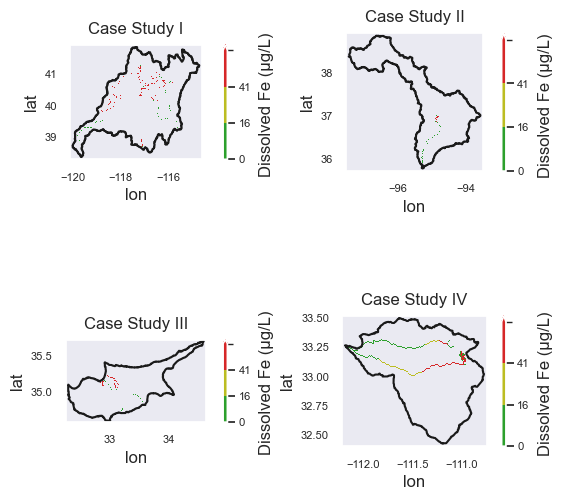

In [246]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

vars_ferric = ["ferric_iron"] * 4
vars_ferrous = ["ferrous_iron"] * 4

csi_fe3, csii_fe3, csiii_fe3, csiv_fe3 = get_var_from_amd(vars_ferric)
csi_fe2, csii_fe2, csiii_fe2, csiv_fe2 = get_var_from_amd(vars_ferrous)

csi_dis = csi_fe3 + csi_fe2
csii_dis = csii_fe3 + csii_fe2
csiii_dis = csiii_fe3 + csiii_fe2
csiv_dis = csiv_fe3 + csiv_fe2

cmap = mcolors.ListedColormap(['tab:green', 'tab:olive', 'tab:red'])
bounds = [0, 16, 41, 1e8] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

bar_vars = ["Dissolved Fe"] * 4
units = ["µg/L"] * 4
titles = ["Case Study I", "Case Study II", "Case Study III", "Case Study IV"]

fig, axs = plt.subplots(2, 2, figsize=(textwidth_in, textwidth_in))
axes = axs.flatten()
vars_ = [csi_dis, csii_dis, csiii_dis, csiv_dis]
aois = [csi_aoi, csii_aoi, csiii_aoi, csiv_aoi]

for ax, var, bar_title, unit, aoi, plot_title in zip(axes, vars_, bar_vars, units, aois, titles):
    arr = var.isel(time=-1).where(var.isel(time=-1) > 0)
    
    mesh = arr.plot(ax=ax, add_colorbar=False, cmap=cmap, norm=norm)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.01)
    
    cb = fig.colorbar(mesh, cax=cax, extend='max')
    cb.set_label(f"{bar_title} ({unit})", labelpad=6)
    
    cb.set_ticks([0, 16, 41])
    cb.ax.set_yticklabels(['0', '16', '41'])
    cb.ax.tick_params(labelsize=8, pad=2)

    ax.set_title(plot_title, pad=8)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=8)

    aoi.boundary.plot(ax=ax, edgecolor="k")

    bounds_geom = aoi.total_bounds
    dx = bounds_geom[2] - bounds_geom[0]
    dy = bounds_geom[3] - bounds_geom[1]
    pad = 0.02
    ax.set_xlim(bounds_geom[0] - dx * pad, bounds_geom[2] + dx * pad)
    ax.set_ylim(bounds_geom[1] - dy * pad, bounds_geom[3] + dy * pad)

fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95,
                    wspace=0.10, hspace=0.12)
fig.tight_layout()
fig.savefig("../images/iron_impact_maps.png", dpi = 300, bbox_inches = "tight")

<h2>Spearman correlation + n (amount of observation/model value pairs) vs. FZE plot

In [47]:
def plot_case_study_fits(ax, df, title, xlim=None, ylim=None, cs_colors = None):
    if cs_colors is None:
        cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red"]
    scatter =sns.scatterplot(data=df, x="n", y="FZE", hue="Case Study", palette=cs_colors, ax=ax, legend=False, alpha=0.7, s = 10)
    for (color, label) in zip(cs_colors, df["Case Study"].unique()):
        data = df[df["Case Study"] == label]
        if len(data) < 2:
            continue
        slope, intercept = np.polyfit(data["n"], data["FZE"], 1)
        x_fit = np.linspace(data["n"].min(), data["n"].max(), 100)
        y_fit = slope * x_fit + intercept
        lines = ax.plot(x_fit, y_fit, linewidth=1, label=f"{label} fit", linestyle = "-", color = color)
    ax.set_title(title)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    slope, intercept = np.polyfit(df["n"], df["FZE"], 1)
    x_fit = np.linspace(df["n"].min(), df["n"].max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, color="black", linewidth=1, label="Overall fit", linestyle ="--")
    

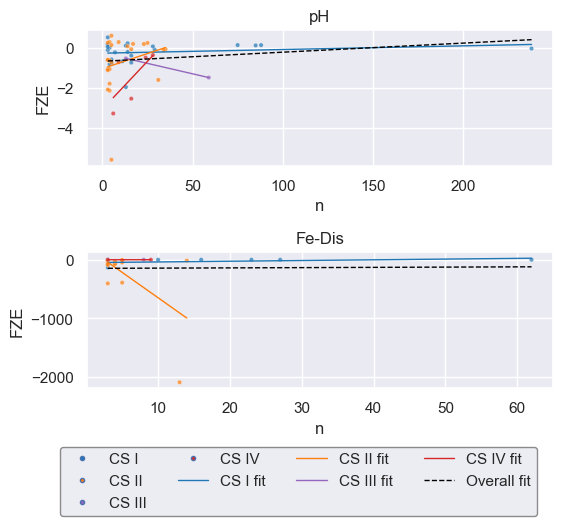

In [49]:
textwidth_in = 418.25368 / 72.27
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(textwidth_in, textwidth_in * 0.8))
cs_labels = ["CS I", "CS II", "CS III", "CS IV", "Overall"]
csi_ph["Case Study"] = "CS I"
csii_ph["Case Study"] = "CS II"
csiii_ph["Case Study"] = "CS III"
csiv_ph["Case Study"] = "CS IV"
ph_data = pd.concat([csi_ph, csii_ph, csiii_ph, csiv_ph], ignore_index=True)

plot_case_study_fits(ax1, ph_data, "pH")

csi_fe_dis["Case Study"] = "CS I"
csii_fe_dis["Case Study"] = "CS II"
csiii_fe_dis["Case Study"] = "CS III"
csiv_fe_dis["Case Study"] = "CS IV"
fe_data = pd.concat([csi_fe_dis, csii_fe_dis, csiii_fe_dis, csiv_fe_dis], ignore_index=True)

plot_case_study_fits(ax2, fe_data, "Fe-Dis")

import matplotlib.lines as mlines
cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red", "black"]
marker_handles = [
    mlines.Line2D([0], [0],
    marker='o', linestyle='None',
    markerfacecolor=color,
    markersize=3, label=label)
    for color, label in zip(cs_colors, cs_labels) if label != "Overall"
    ]

line_handles = [
    mlines.Line2D([0], [0],
    linestyle='-', color=color, linewidth=1,
    label=f"{label} fit")
    for color, label in zip(cs_colors, cs_labels) if label != "Overall"
]

line_handles.append(
    mlines.Line2D([0], [0],
    linestyle='--', color='black', linewidth=1,
    label="Overall fit")
)

fig.legend(
    handles=marker_handles + line_handles,
    loc='lower center',
    bbox_to_anchor=(0.53, -0.15),
    bbox_transform=fig.transFigure,
    ncol=4,
    framealpha=0.9,
    edgecolor='gray'
)
plt.tight_layout()
fig.savefig("../images/fze_vs_n_fits.png", dpi=300, bbox_inches="tight")

In [69]:
from scipy.stats import spearmanr
import statsmodels


In [86]:
def spearman_corr_scatterline_plot(df1, df2, textwidth_in=418.25368 / 72.27):
    cs_colors = {"CS I": "tab:blue", "CS II": "tab:orange", "CS III": "tab:purple", "CS IV": "tab:red"}
    fig, axes = plt.subplots(2, 1, figsize=(textwidth_in, textwidth_in * 0.8))

    corr_values = []
    p_values = []
    for ax, df in zip(axes, [df1, df2]):
        scatter = sns.scatterplot(data=df, x="n", y="FZE", hue="Case Study", palette=cs_colors, alpha=0.7, s=10, ax=ax, legend=False)
        for label in df["Case Study"].unique():
            data = df[df["Case Study"] == label]
            if len(data) < 2:
                continue
            slope, intercept = np.polyfit(data["n"], data["FZE"], 1)
            x_line = np.linspace(data["n"].min(), data["n"].max(), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, label=f"{label} fit", color=cs_colors[label])

        slope, intercept = np.polyfit(df["n"], df["FZE"], 1)
        x_line = np.linspace(df["n"].min(), df["n"].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color="black", linestyle="--", label="Overall fit")

        corr_coef, p_value = spearmanr(df["n"], df["FZE"])
        ax.set_xlabel("n")
        ax.set_ylabel("FZE")
        corr_values.append(corr_coef)
        p_values.append(p_value)

    axes[0].set_title("pH")
    axes[1].set_title("Fe-Dis")
    plt.tight_layout()

    import matplotlib.lines as mlines
    cs_colors = ["tab:blue", "tab:orange", "tab:purple", "tab:red", "black"]
    marker_handles = [
        mlines.Line2D([0], [0],
        marker='o', linestyle='None',
        markerfacecolor=color,
        markersize=3, label=label)
        for color, label in zip(cs_colors, cs_labels) if label != "Overall"
        ]

    line_handles = [
        mlines.Line2D([0], [0],
        linestyle='-', color=color, linewidth=1,
        label=f"{label} fit")
        for color, label in zip(cs_colors, cs_labels) if label != "Overall"
    ]

    line_handles.append(
        mlines.Line2D([0], [0],
        linestyle='--', color='black', linewidth=1,
        label="Overall fit")
    )

    fig.legend(
        handles=marker_handles + line_handles,
        loc='lower center',
        bbox_to_anchor=(0.53, -0.15),
        bbox_transform=fig.transFigure,
        ncol=4,
        framealpha=0.9,
        edgecolor='gray'
    )
    return fig, corr_values, p_values


Spearman correlation coefficient (pH): 0.1246, p-value: 0.369
Spearman correlation coefficient (Fe-Dis): 0.4640, p-value: 0.019


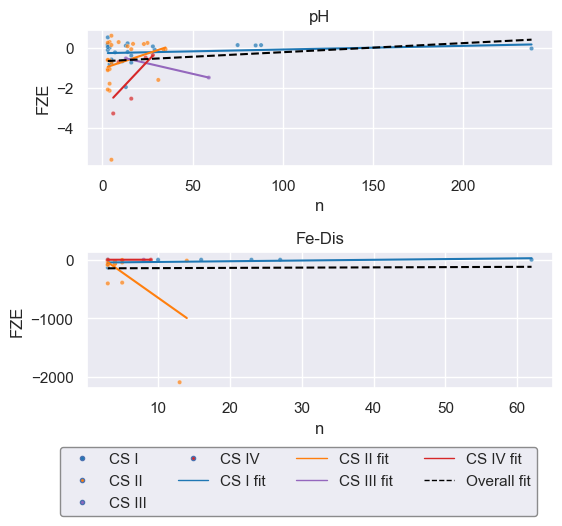

In [87]:
fig, corr, p_val = spearman_corr_scatterline_plot(ph_data, fe_data)
fig.savefig("../images/fze_vs_n_fits.png", dpi=300, bbox_inches="tight")
print(f"Spearman correlation coefficient (pH): {corr[0]:.4f}, p-value: {round(p_val[0], 3)}")
print(f"Spearman correlation coefficient (Fe-Dis): {corr[1]:.4f}, p-value: {round(p_val[1], 3)}")